# Supplementary Figure S6: Paired-pulse ISI dependence and active-zone calcium variability

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from plot_config import (
    get_condition,
    apply_style,
    strip_spines,
    panel_labeler,
    label_panel,
    save_figure,
)

apply_style()

## Configuration

In [2]:
# ============================================================
# CONFIG
# ============================================================

from pathlib import Path

CONDITION_ORDER = ["control", "ad_5x_ryr"]  # draw order == legend order

# Panels a/b: paired-pulse protocol
PAIRED_PULSE_DIR = Path("paired_pulse_summary")
SWEEP_ISI_FILES = {
    "control": PAIRED_PULSE_DIR / "sweep_isi_control.csv",
    "ad_5x_ryr": PAIRED_PULSE_DIR / "sweep_isi_ad.csv",
}
DEEPDIVE_AZCV_FILES = {
    "control": PAIRED_PULSE_DIR / "deepdive_control_az_cv_over_time.csv",
    "ad_5x_ryr": PAIRED_PULSE_DIR / "deepdive_ad_az_cv_over_time.csv",
}
AZCV_SMOOTH_WINDOW = 21  # samples (~1.05 ms at the 50 us native step); odd, for centered smoothing

## Load panel a: P11 vs ISI (paired-pulse, VDCC=80)

In [3]:
def load_sweep_isi(key):
    arr = np.genfromtxt(SWEEP_ISI_FILES[key], delimiter=",", names=True)
    arr = arr[~np.isnan(arr["p11"])]
    return arr[np.argsort(arr["isi_ms"])]


sweep_isi = {key: load_sweep_isi(key) for key in CONDITION_ORDER}
for key in CONDITION_ORDER:
    print(f"{key:12s}  {len(sweep_isi[key])} usable ISI points")

control       10 usable ISI points
ad_5x_ryr     11 usable ISI points


## Load panel b: CV of [Ca$^{2+}$]$_{AZ}$ over time (paired-pulse deep-dive, VDCC=80/ISI=40ms)

In [4]:
deepdive_azcv = {
    key: np.genfromtxt(DEEPDIVE_AZCV_FILES[key], delimiter=",", names=True)
    for key in CONDITION_ORDER
}


def _smooth(y, window):
    if window <= 1:
        return y
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode="same")

## Figure

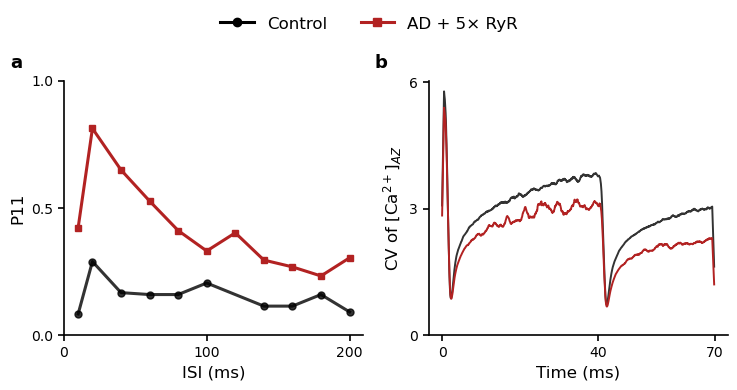

In [5]:
SUPP_FIGSIZE = (7.5, 3.8)
SUPP_FIGURE_PATH = "figS6_paired_pulse_ISI_sync_coupling.png"
SAVE_SUPP_FIGURE = True

fig, (ax_isi, ax_azcv) = plt.subplots(1, 2, figsize=SUPP_FIGSIZE)
panel = panel_labeler()

# a. P11 vs ISI, paired-pulse (VDCC=80)
for key in CONDITION_ORDER:
    cond = get_condition(key)
    d = sweep_isi[key]
    ax_isi.plot(d["isi_ms"], d["p11"], color=cond.color, marker=cond.marker,
                alpha=cond.alpha, zorder=cond.zorder, markersize=5)
ax_isi.set_xlabel("ISI (ms)")
ax_isi.set_ylabel("P11")
ax_isi.set_xticks([0, 100, 200])
ax_isi.set_yticks([0.0, 0.5, 1.0])  # same probability-axis convention as Fig. 1a/b
strip_spines(ax_isi)
label_panel(ax_isi, next(panel))

# b. CV of [Ca2+]AZ vs time, paired-pulse (VDCC=80, ISI=40ms)
for key in CONDITION_ORDER:
    cond = get_condition(key)
    d = deepdive_azcv[key]
    t_ms = d["time_s"] * 1000.0
    cv_smooth = _smooth(d["cv_az"], AZCV_SMOOTH_WINDOW)
    ax_azcv.plot(t_ms, cv_smooth, color=cond.color, linewidth=1.4,
                 alpha=cond.alpha, zorder=cond.zorder)
ax_azcv.set_xlabel("Time (ms)")
ax_azcv.set_ylabel(r"CV of [Ca$^{2+}$]$_{AZ}$")
ax_azcv.set_xticks([0, 40, 70])  # 0/40ms = AP1/AP2 onset, 70ms = window end
ax_azcv.set_yticks([0, 3, 6])  # same y-scale as fig10 panel d, for direct comparison
strip_spines(ax_azcv)
label_panel(ax_azcv, next(panel))

legend_handles = [
    Line2D([0], [0], color=get_condition(k).color, marker=get_condition(k).marker,
           label=get_condition(k).label) for k in CONDITION_ORDER
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.04))

fig.tight_layout(rect=[0, 0, 1, 0.95])

if SAVE_SUPP_FIGURE:
    save_figure(fig, SUPP_FIGURE_PATH)

plt.show()